# Wzorce cenowe na rynku energii w Polsce

**Pytanie tego notebooka:** o jakiej porze energia elektryczna jest najtańsza, jak silny
jest ten wzorzec i czy zmienia się w czasie?

Dane: rynkowa cena rozliczeniowa (RCE) z API PSE, rozdzielczość 15 minut, połączona
z generacją fotowoltaiki i wiatru oraz zapotrzebowaniem KSE. Zakres 14.06.2024 - 19.08.2026,
76 512 kwadransów w 797 dobach. Przygotowanie danych: `scripts/import_data.py`
i `scripts/prepare_data.py`.

**Uwaga o zakresie:** RCE to cena hurtowa na rynku dnia następnego, a nie cena z faktury
odbiorcy. Faktura zawiera dodatkowo dystrybucję, opłaty i marżę sprzedawcy. Ten notebook
opisuje wzorce cenowe na rynku, nie symuluje rachunku.

## 1. Wczytanie i kontrola danych

Zanim cokolwiek policzę, sprawdzam trzy rzeczy: rozmiar zbioru, zakres dat i braki.
Kontrola kompletności odbyła się już w skryptach, ale notebook ma być samowystarczalny -
jeśli ktoś wczyta zły plik, ma się to wydać tutaj, a nie trzy komórki niżej.

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
PROJECT_DIR = Path.cwd().resolve().parent
PROCESSED_CSV = PROJECT_DIR / "data" / "processed" / "energia_pl.csv"

In [3]:
df = pd.read_csv(PROCESSED_CSV)
df.shape

(76512, 17)

In [4]:
print(f"date range: {df['business_date'].min()} - {df['business_date'].max()}")

date range: 2024-06-14 - 2026-08-19


In [5]:
df.isna().sum()

dtime                 0
period                0
rce_pln               0
dtime_utc             0
period_utc            0
business_date         0
publication_ts        0
publication_ts_utc    0
pv                    0
wi                    0
demand                0
hour                  0
day_of_week           0
month                 0
is_weekend            0
day_name              0
res_share             0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rce_pln,76512.0,457.710581,247.718245,-1457.590000,372.937500,451.350000,555.150000,2751.720000
pv,76512.0,2414.193727,3397.043792,0.000000,0.000000,236.764500,4436.499250,14564.549000
wi,76512.0,2416.276686,1844.241745,18.545000,949.796000,1929.240000,3492.744750,8906.377000
demand,76512.0,18182.758329,3108.312771,10463.962000,15670.274750,18305.731500,20288.551000,27733.885000
hour,76512.0,11.500000,6.922232,0.000000,5.750000,11.500000,17.250000,23.000000
day_of_week,76512.0,3.000000,2.001267,0.000000,1.000000,3.000000,5.000000,6.000000
month,76512.0,6.569113,3.309535,1.000000,4.000000,7.000000,9.000000,12.000000
res_share,76512.0,0.267721,0.186595,0.000929,0.113634,0.222287,0.396788,0.869318


## 2. Profil dobowy - mediana i średnia obok siebie

Liczę obie miary celowo, bo odpowiadają na różne pytania.

**Mediana** opisuje typową godzinę i jest odporna na skoki - a te na rynku energii są
ekstremalne (od -1 458 do +2 752 PLN/MWh). **Średnia** reaguje na każdą wartość i to ona
decyduje o rachunku, bo koszt to suma iloczynów zużycia i ceny, a nie wartość typowa.

Reguła przyjęta w tym projekcie: **mediana do opisywania wzorców, średnia do liczenia
pieniędzy.**

In [7]:
hourly = df.groupby("hour")["rce_pln"].agg(["median", "mean"])
hourly

,median,mean
hour,,
0,448.595,443.308861
1,427.340,418.162497
2,414.960,404.726424
3,413.420,402.285367
4,417.220,407.800402
5,436.640,430.175442
6,512.160,507.894307
7,537.835,552.436851
8,488.185,506.266013


### Kontrola skośności: różnica średnia - mediana

W statystykach globalnych średnia (457,71) i mediana (451,35) różniły się o 1,4% - rozkład
wyglądał na symetryczny. To myląca obserwacja: ceny ujemne w środku dnia i skoki wieczorne
znoszą się nawzajem, gdy wrzucić całą dobę do jednego worka.

Poniższa kolumna sprawdza, czy po rozbiciu na godziny znoszenie ustaje. Interpretacja znaku:

- **wartość ujemna** - średnia poniżej mediany, czyli ogon w dół (rzadkie ceny bardzo niskie lub ujemne)
- **wartość dodatnia** - średnia powyżej mediany, czyli ogon w górę (rzadkie skoki cenowe)

In [8]:
hourly["mean_minus_median"] = hourly["mean"] - hourly["median"]
hourly

,median,mean,mean_minus_median
hour,,,
0,448.595,443.308861,-5.286139
1,427.340,418.162497,-9.177503
2,414.960,404.726424,-10.233576
3,413.420,402.285367,-11.134633
4,417.220,407.800402,-9.419598
5,436.640,430.175442,-6.464558
6,512.160,507.894307,-4.265693
7,537.835,552.436851,14.601851
8,488.185,506.266013,18.081013


**Wynik.** Znak odwraca się dokładnie na granicach szczytów:

| Godziny | Znak | Interpretacja |
|---|---|---|
| 9-15 | ujemny, do -42 | dolina w środku dnia z ogonem cen ujemnych |
| 7-8 oraz 16-23 | dodatni, do +77 | szczyty ze skokami w górę |

Dwie liczby do zapamiętania:

- **mediana o 20:00 jest o 118% wyższa niż o 12:00** (654 wobec 300 PLN/MWh)
- ta sama para godzin liczona **średnią** daje **+175%** - czyli miara zmienia wielkość
  efektu o 57 punktów procentowych, co potwierdza, że do rekomendacji oszczędnościowej
  trzeba średniej

Kształt doby - dolina cenowa w środku dnia i garb wieczorny - to podręcznikowa
**krzywa kaczki** (*duck curve*): fotowoltaika wypiera drogie jednostki w południe,
a po zachodzie słońca system sięga po najdroższe rezerwy przy rosnącym zapotrzebowaniu.

## 3. Profil dobowy rok do roku

Skoro dolina w środku dnia bierze się z fotowoltaiki, a moc zainstalowana PV w Polsce
rosła w latach 2024-2026, to profil powinien się zmieniać. Poniższy wykres porównuje
trzy lata.

**Wynik tego wykresu jest mylący** i sprawdzam go w sekcji 4 - powód opisany niżej.

In [9]:
df["year"] = pd.to_datetime(df["business_date"]).dt.year
yearly_median = df.groupby(["year", "hour"])["rce_pln"].agg("median")
yearly_median

year  hour
2024  0       441.140
      1       396.880
      2       383.880
      3       384.130
      4       388.100
               ...   
2026  19      685.150
      20      695.495
      21      608.755
      22      556.655
      23      507.795
Name: rce_pln, Length: 72, dtype: float64

<Axes: xlabel='hour'>

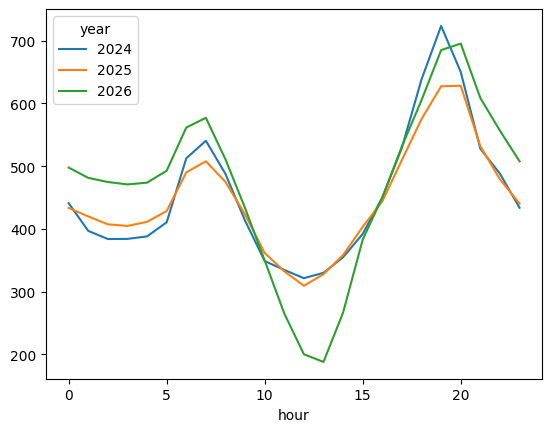

In [10]:
df.pivot_table(index="hour", columns="year", values="rce_pln", aggfunc="median").plot()

## 4. Kontrola sezonowa profilu dobowego

Wykres powyżej porównuje całe lata, ale zakres danych nie pokrywa się między nimi:
2024 zaczyna się 14 czerwca (brak zimy i wiosny), 2026 kończy się 19 sierpnia (brak jesieni).
Ponieważ dolina cenowa w środku dnia jest zjawiskiem letnim, rok z wiekszym udzialem lata ma
medianę południową sztucznie zaniżoną. Część spadku widocznego na wykresie może być
artefaktem składu próbki, a nie zmianą rynku.

Poniżej dwa testy. W **każdym z nich** porównywane lata obejmują dokładnie ten sam
wycinek kalendarza - ale same testy używają różnych wycinków, bo każdy kupuje coś innego:

| | Okno | Lata | Co daje | Czym płaci |
|---|---|---|---|---|
| Test 1 | 67 dni (14.06 - 19.08) | 2024, 2025, 2026 | wszystkie trzy lata | mała próba |
| Test 2 | 231 dni (01.01 - 19.08) | 2025, 2026 | próba 3,5× większa | brak 2024 |

Okna są różne celowo: to jest kompromis między **porównywalnością** a **wielkością próby**.
Jeśli oba testy prowadzą do tego samego wniosku, wniosek nie zależy od wyboru okna.

In [11]:
df["month_day"] = pd.to_datetime(df["business_date"]).dt.strftime("%m-%d")

days_per_year = df.groupby("year")["business_date"].nunique()
summer_days = df[df["month"].isin([6, 7, 8])].groupby("year")["business_date"].nunique()

year_coverage = pd.DataFrame({
    "days": days_per_year,
    "summer days": summer_days,
    "% summer": (summer_days / days_per_year * 100).round(0),
})
year_coverage

,days,summer days,% summer
year,,,
2024,201,79,39.0
2025,365,92,25.0
2026,231,80,35.0


### Test 1 - wspólne okno letnie (14.06 - 19.08), wszystkie trzy lata

Najdłuższy przedział kalendarzowy dostępny we wszystkich trzech latach: 67 dni
(17 dni czerwca + 31 lipca + 19 sierpnia).

In [12]:
summer_window = df[(df["month_day"] >= "06-14") & (df["month_day"] <= "08-19")]
print("days per year:", summer_window.groupby("year")["business_date"].nunique().to_dict())

summer_profile = summer_window.pivot_table(index="hour", columns="year", values="rce_pln", aggfunc="median")

print("trough:   ", summer_profile.min().round(0).to_dict())
print("peak:     ", summer_profile.max().round(0).to_dict())
print("amplitude:", (summer_profile.max() - summer_profile.min()).round(0).to_dict())

summer_profile.round(0)

days per year: {2024: 67, 2025: 67, 2026: 67}
trough:    {2024: 247.0, 2025: 63.0, 2026: 112.0}
peak:      {2024: 897.0, 2025: 743.0, 2026: 884.0}
amplitude: {2024: 650.0, 2025: 681.0, 2026: 773.0}


year,2024,2025,2026
hour,,,
0,490.0,443.0,618.0
1,416.0,424.0,585.0
2,395.0,405.0,562.0
3,392.0,403.0,553.0
4,397.0,403.0,556.0
5,414.0,417.0,574.0
6,525.0,466.0,628.0
7,521.0,464.0,595.0
8,458.0,432.0,523.0


### Test 2 - długa próba, 2025 vs 2026 (01.01 - 19.08)

Okno letnie ma tylko 67 dni na rok, więc pojedyncze anomalie ważą w nim dużo.
Dla lat 2025 i 2026 można porównać 231 dni - 2024 odpada, bo dane zaczynają się w czerwcu.

In [13]:
long_window = df[(df["month_day"] <= "08-19") & (df["year"].isin([2025, 2026]))]
print("days per year:", long_window.groupby("year")["business_date"].nunique().to_dict())

long_profile = long_window.pivot_table(index="hour", columns="year", values="rce_pln", aggfunc="median")

print("trough:   ", long_profile.min().round(0).to_dict())
print("peak:     ", long_profile.max().round(0).to_dict())
print("amplitude:", (long_profile.max() - long_profile.min()).round(0).to_dict())

long_profile.round(0)

days per year: {2025: 231, 2026: 231}
trough:    {2025: 193.0, 2026: 188.0}
peak:      {2025: 658.0, 2026: 695.0}
amplitude: {2025: 465.0, 2026: 508.0}


year,2025,2026
hour,,
0,446.0,498.0
1,426.0,481.0
2,411.0,475.0
3,409.0,471.0
4,414.0,474.0
5,430.0,493.0
6,496.0,562.0
7,508.0,577.0
8,462.0,511.0


### Wniosek

**Hipoteza „dolina pogłębia się z roku na rok" nie przechodzi testu.**

Między 2025 a 2026, na próbie 231 dni, dolina praktycznie się nie zmieniła (193 → 188 PLN/MWh,
czyli -2,6%, w granicach szumu). Pogłębienie miało miejsce wcześniej, między 2024 a 2025.
To, co rośnie między 2025 a 2026, to **szczyt wieczorny** (658 → 695).

**Teza odporna na sposób krojenia danych: rośnie amplituda doby.**

| Okno | Amplituda (szczyt - dolina) |
|---|---|
| letnie, 67 dni | 650 → 681 → 773 |
| długie, 231 dni | 465 → 508 |

Rozpiętość między najtańszą a najdroższą godziną powiększa się w każdym porównaniu.
Ma to bezpośrednie przełożenie na rekomendację: **przesuwanie zużycia na tańsze pasma
jest z roku na rok bardziej opłacalne**.

**Ograniczenia:** trzy punkty czasowe to nie trend, tylko wskazówka. Okno letnie liczy
67 dni na rok, więc pojedyncze anomalie pogodowe ważą w nim dużo. Wzrost poziomu cen
nocnych w 2026 (o około 40% względem lat poprzednich) nie da się wyjaśnić fotowoltaiką -
PV nie pracuje w nocy - a danych o kosztach paliw i uprawnień CO2 ten zbiór nie zawiera.